In [1]:
from google.colab import files

uploaded = files.upload()


Saving finance_fraud_data.csv to finance_fraud_data.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
csv_files = list(Path("/content").glob("*.csv"))

if not csv_files:
    raise FileNotFoundError("No CSV dataset found")

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("File:", DATA_PATH.name)
print("Shape:", df.shape)

df.head()

Dataset loaded successfully
File: finance_fraud_data.csv
Shape: (15000, 12)


,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
0,TRX-000001,2025-02-06 18:46:00,CUST-1727,1985.97,Luxury_Goods,0.0123,Android,0.89,94.75,0,0,1
1,TRX-000002,2025-03-25 09:19:00,CUST-1607,30.45,Food_Dining,0.0123,Android,0.85,26.00,0,0,0
2,TRX-000003,2025-02-17 17:05:00,CUST-1596,10.08,Transport,0.0123,Web_Browser,0.80,103.97,0,0,0
3,TRX-000004,2025-01-13 08:26:00,CUST-1980,8.20,Food_Dining,0.0123,Android,0.42,92.27,0,0,0
4,TRX-000005,2025-03-16 08:38:00,CUST-1235,181.07,Electronics,0.0123,Android,0.94,144.05,1,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        15000 non-null  object 
 1   Timestamp             15000 non-null  object 
 2   Customer_ID           15000 non-null  object 
 3   Amount                15000 non-null  float64
 4   Merchant_Category     15000 non-null  object 
 5   Distance_from_Home    15000 non-null  float64
 6   Device_Type           15000 non-null  object 
 7   IP_Risk_Score         15000 non-null  float64
 8   Avg_Spending_Habit    15000 non-null  float64
 9   Is_Weekend            15000 non-null  int64  
 10  Is_Night_Transaction  15000 non-null  int64  
 11  Is_Fraud              15000 non-null  int64  
dtypes: float64(4), int64(3), object(5)
memory usage: 1.4+ MB


In [5]:
df.describe(include="all")

,Transaction_ID,Timestamp,Customer_ID,Amount,Merchant_Category,Distance_from_Home,Device_Type,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
count,15000,15000,15000,15000.000000,15000,15000.000000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,15000,14122,1000,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN
top,TRX-015000,2025-03-21 08:52:00,CUST-1664,NaN,Groceries,NaN,Android,NaN,NaN,NaN,NaN,NaN
freq,1,4,28,NaN,4532,NaN,6788,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,197.627147,NaN,0.258520,NaN,0.501900,99.813583,0.286467,0.207800,0.122333
std,NaN,NaN,NaN,556.909653,NaN,1.058511,NaN,0.290001,29.930782,0.452125,0.405746,0.327681
min,NaN,NaN,NaN,2.580000,NaN,0.012300,NaN,0.000000,-36.680000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,22.167500,NaN,0.012300,NaN,0.250000,79.700000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,38.120000,NaN,0.012300,NaN,0.500000,100.050000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,69.905000,NaN,0.012300,NaN,0.750000,120.050000,1.000000,0.000000,0.000000


In [6]:
print("Columns:")
for column in df.columns:
    print(f"- {column}")

Columns:
- Transaction_ID
- Timestamp
- Customer_ID
- Amount
- Merchant_Category
- Distance_from_Home
- Device_Type
- IP_Risk_Score
- Avg_Spending_Habit
- Is_Weekend
- Is_Night_Transaction
- Is_Fraud


In [7]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(missing_values)

,Missing Count,Missing Percentage
Transaction_ID,0,0.0
Timestamp,0,0.0
Customer_ID,0,0.0
Amount,0,0.0
Merchant_Category,0,0.0
Distance_from_Home,0,0.0
Device_Type,0,0.0
IP_Risk_Score,0,0.0
Avg_Spending_Habit,0,0.0
Is_Weekend,0,0.0


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [9]:
unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[column].nunique() for column in df.columns],
    "Data Type": df.dtypes.astype(str).values
})

display(unique_values)

,Column,Unique Values,Data Type
0,Transaction_ID,15000,object
1,Timestamp,14122,object
2,Customer_ID,1000,object
3,Amount,8562,float64
4,Merchant_Category,6,object
5,Distance_from_Home,2,float64
6,Device_Type,3,object
7,IP_Risk_Score,101,float64
8,Avg_Spending_Habit,8341,float64
9,Is_Weekend,2,int64


In [10]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    print(f"\n{'=' * 50}")
    print(column)
    print(df[column].value_counts().head(20))


Transaction_ID
Transaction_ID
TRX-015000    1
TRX-000001    1
TRX-000002    1
TRX-000003    1
TRX-000004    1
TRX-000005    1
TRX-000006    1
TRX-000007    1
TRX-014984    1
TRX-014983    1
TRX-014982    1
TRX-014981    1
TRX-014980    1
TRX-014979    1
TRX-014978    1
TRX-014977    1
TRX-014976    1
TRX-014975    1
TRX-014974    1
TRX-014973    1
Name: count, dtype: int64

Timestamp
Timestamp
2025-03-21 08:52:00    4
2025-01-27 22:39:00    3
2025-03-30 05:25:00    3
2025-01-29 15:01:00    3
2025-03-18 19:09:00    3
2025-03-18 12:23:00    3
2025-03-03 10:03:00    3
2025-03-10 11:32:00    3
2025-02-21 17:18:00    3
2025-01-13 20:11:00    3
2025-03-14 05:22:00    3
2025-03-07 05:35:00    3
2025-02-18 00:25:00    3
2025-02-07 19:00:00    3
2025-02-13 17:59:00    3
2025-03-12 20:26:00    3
2025-02-11 21:43:00    3
2025-01-02 05:19:00    3
2025-02-26 00:09:00    3
2025-02-10 11:42:00    3
Name: count, dtype: int64

Customer_ID
Customer_ID
CUST-1664    28
CUST-1241    27
CUST-1001    27
CUS

In [11]:
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working shape:", df_clean.shape)

Original shape: (15000, 12)
Working shape: (15000, 12)


In [12]:
numeric_columns = df_clean.select_dtypes(include=["number"]).columns

for column in numeric_columns:
    print(f"\n{'=' * 50}")
    print(f"Column: {column}")
    print("Minimum:", df_clean[column].min())
    print("Maximum:", df_clean[column].max())
    print("Negative values:", (df_clean[column] < 0).sum())


Column: Amount
Minimum: 2.58
Maximum: 7987.24
Negative values: 0

Column: Distance_from_Home
Minimum: 0.0123
Maximum: 4.8088
Negative values: 0

Column: IP_Risk_Score
Minimum: 0.0
Maximum: 1.0
Negative values: 0

Column: Avg_Spending_Habit
Minimum: -36.68
Maximum: 200.55
Negative values: 4

Column: Is_Weekend
Minimum: 0
Maximum: 1
Negative values: 0

Column: Is_Night_Transaction
Minimum: 0
Maximum: 1
Negative values: 0

Column: Is_Fraud
Minimum: 0
Maximum: 1
Negative values: 0


In [13]:
df_clean["Timestamp"] = pd.to_datetime(
    df_clean["Timestamp"],
    errors="coerce"
)

print("Invalid timestamps:", df_clean["Timestamp"].isna().sum())

print("Date range:")
print("Start:", df_clean["Timestamp"].min())
print("End:", df_clean["Timestamp"].max())

Invalid timestamps: 0
Date range:
Start: 2025-01-01 00:17:00
End: 2025-03-31 23:59:00


In [14]:
transaction_id_duplicates = df_clean["Transaction_ID"].duplicated().sum()

print(
    f"Duplicate Transaction_ID values: "
    f"{transaction_id_duplicates}"
)

Duplicate Transaction_ID values: 0


In [15]:
print(
    df_clean["Is_Fraud"]
    .value_counts(dropna=False)
    .sort_index()
)

valid_target = df_clean["Is_Fraud"].isin([0, 1]).all()

print("\nTarget contains only 0 and 1:", valid_target)

Is_Fraud
0    13165
1     1835
Name: count, dtype: int64

Target contains only 0 and 1: True


,count
Is_Fraud,
0,13165
1,1835


,proportion
Is_Fraud,
0,87.77
1,12.23


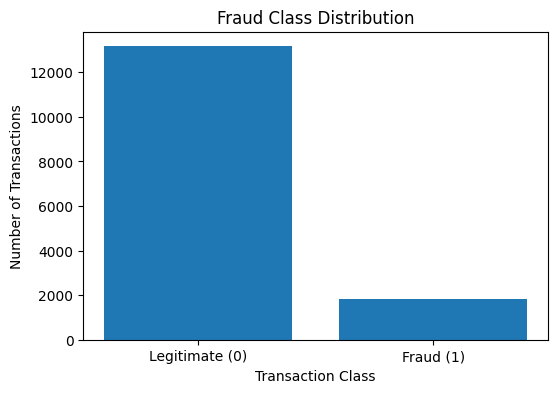

In [16]:
fraud_counts = df_clean["Is_Fraud"].value_counts().sort_index()

display(fraud_counts)

fraud_percentage = (
    df_clean["Is_Fraud"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
).round(2)

display(fraud_percentage)

plt.figure(figsize=(6, 4))
plt.bar(
    ["Legitimate (0)", "Fraud (1)"],
    [fraud_counts[0], fraud_counts[1]]
)
plt.title("Fraud Class Distribution")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

### Finding

The dataset contains **13,165 legitimate transactions (87.77%)** and **1,835 fraudulent transactions (12.23%)**. Therefore, the target variable is imbalanced, with legitimate transactions forming the majority class.

However, the imbalance is not extreme. During model development, accuracy alone should not be used as the primary evaluation metric because a model can achieve high accuracy by favoring the majority class. Metrics such as ROC-AUC, PR-AUC, precision, recall, and F1-score will also be evaluated.

In [17]:
numeric_features = [
    "Amount",
    "Distance_from_Home",
    "IP_Risk_Score",
    "Avg_Spending_Habit"
]

display(df_clean[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Amount,15000.0,197.627147,556.909653,2.5800,22.1675,38.1200,69.9050,7987.2400
Distance_from_Home,15000.0,0.258520,1.058511,0.0123,0.0123,0.0123,0.0123,4.8088
IP_Risk_Score,15000.0,0.501900,0.290001,0.0000,0.2500,0.5000,0.7500,1.0000
Avg_Spending_Habit,15000.0,99.813583,29.930782,-36.6800,79.7000,100.0500,120.0500,200.5500


### Finding

The numerical summary provides the range, central tendency, and spread of the key numerical variables: `Amount`, `Distance_from_Home`, `IP_Risk_Score`, and `Avg_Spending_Habit`.

The `Amount` and `Avg_Spending_Habit` features should be examined further for skewness and extreme values. Extreme transaction amounts should not be automatically removed because unusual transactions may represent legitimate fraud-related signals rather than data errors.

`Distance_from_Home` requires additional investigation because earlier inspection showed that it contains only a very small number of unique values despite being stored as a numerical feature.

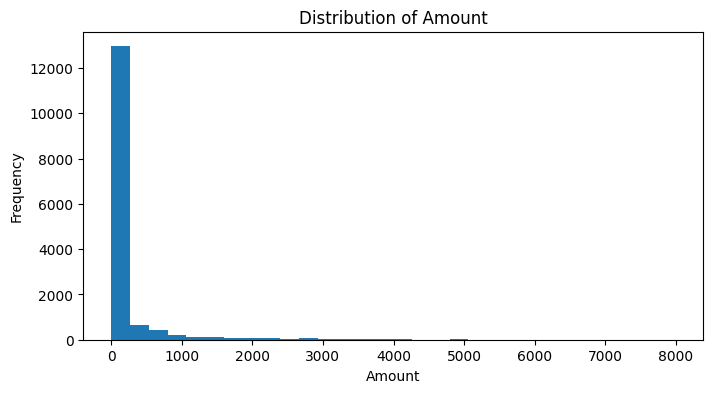

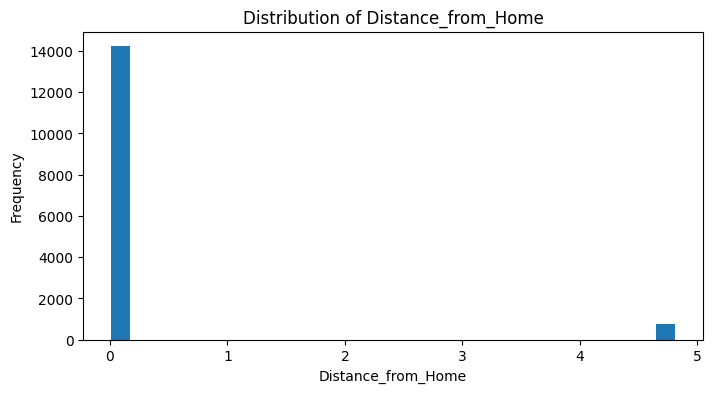

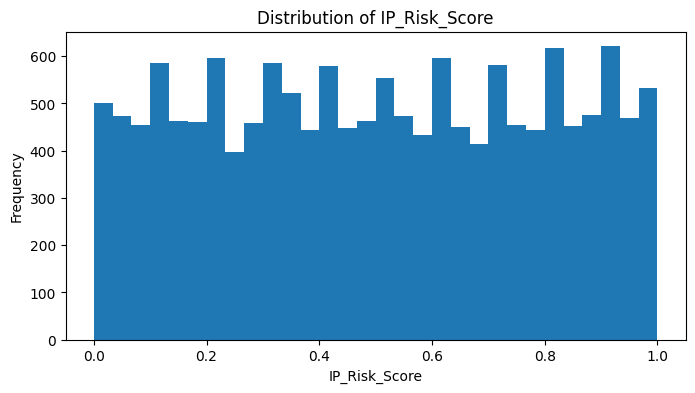

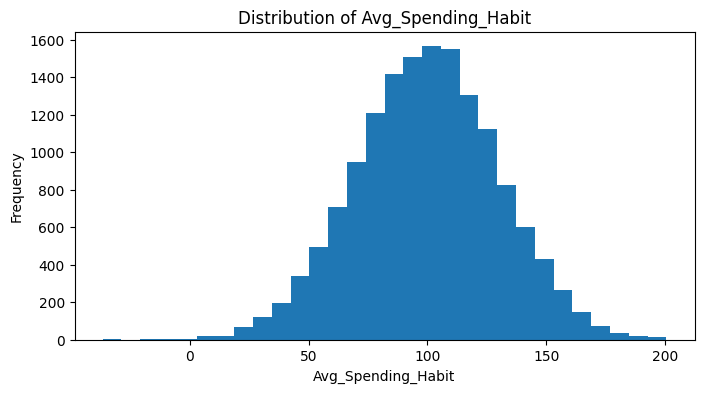

In [18]:
for column in numeric_features:
    plt.figure(figsize=(8, 4))
    plt.hist(df_clean[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Finding

The numerical feature distributions reveal that the variables have different statistical characteristics. In particular, transaction-related financial variables may be skewed, with a large concentration of observations in lower-value ranges and fewer high-value observations.

These high-value observations should not be treated as removable outliers without further investigation. In a fraud detection problem, unusual behavior can be an important predictive signal. Therefore, outlier removal will not be performed automatically.

In [19]:
fraud_numeric_summary = (
    df_clean
    .groupby("Is_Fraud")[numeric_features]
    .agg(["mean", "median", "std"])
    .round(2)
)

display(fraud_numeric_summary)

Amount                  Distance_from_Home               \
             mean  median      std               mean median   std   
Is_Fraud                                                             
0           80.84   35.59   160.97               0.17   0.01  0.86   
1         1035.48  628.96  1245.08               0.89   0.01  1.86   

         IP_Risk_Score              Avg_Spending_Habit                 
                  mean median   std               mean  median    std  
Is_Fraud                                                               
0                 0.48   0.47  0.28             100.02  100.19  29.83  
1                 0.66   0.82  0.30              98.34   99.39  30.64

### Finding

Comparing numerical features across legitimate and fraudulent transactions helps identify variables associated with fraudulent behavior.

The differences in mean and median values indicate whether fraudulent transactions tend to have different transaction amounts, IP risk levels, distances from home, or spending behavior compared with legitimate transactions.

These results represent associations rather than causal relationships. Strong relationships should also be investigated for possible synthetic-data artifacts or target leakage before being relied upon in the final model.

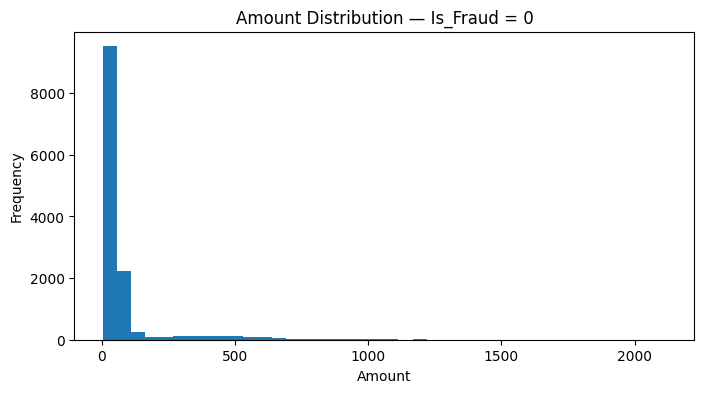

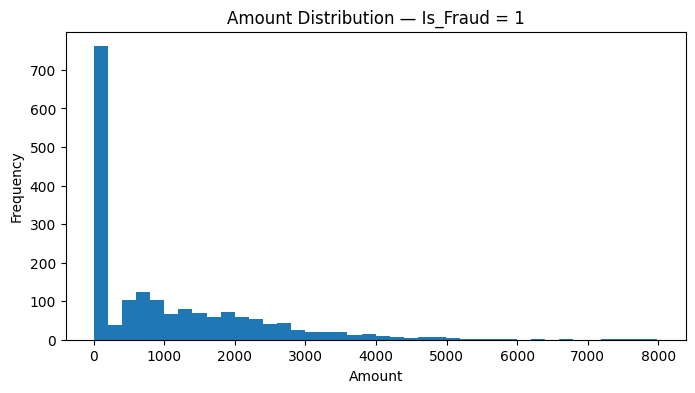

In [20]:
for fraud_label, group in df_clean.groupby("Is_Fraud"):
    plt.figure(figsize=(8, 4))
    plt.hist(group["Amount"], bins=40)
    plt.title(f"Amount Distribution — Is_Fraud = {fraud_label}")
    plt.xlabel("Amount")
    plt.ylabel("Frequency")
    plt.show()

### Finding

Fraudulent transactions have substantially higher transaction amounts than legitimate transactions in this dataset. The average legitimate transaction amount is approximately **80.84**, while the average fraudulent transaction amount is approximately **1035.48**.

This indicates that transaction amount is likely to be an important predictive feature. However, the difference between the two classes is unusually strong, so the feature should be monitored for possible synthetic-data generation patterns. A high transaction amount alone should not be interpreted as fraud; it should be evaluated together with other risk signals.


Fraud statistics by Merchant_Category


,count,Fraud_Rate
Merchant_Category,,
Electronics,1498,23.77
Food_Dining,3759,5.59
Groceries,4532,5.74
Luxury_Goods,722,99.86
Online_Services,1430,6.15
Transport,3059,6.54


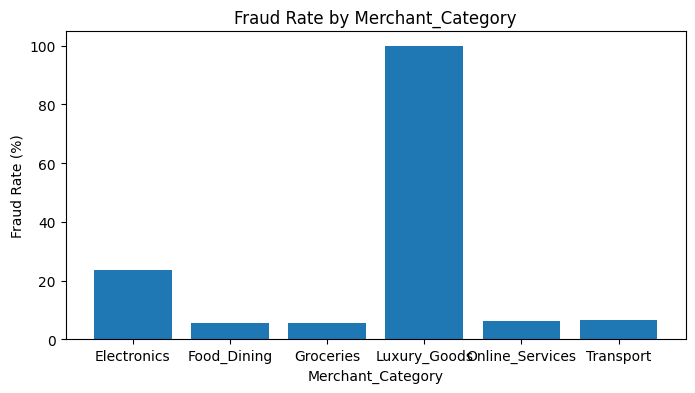


Fraud statistics by Device_Type


,count,Fraud_Rate
Device_Type,,
Android,6788,12.73
Web_Browser,1484,12.20
iOS,6728,11.74


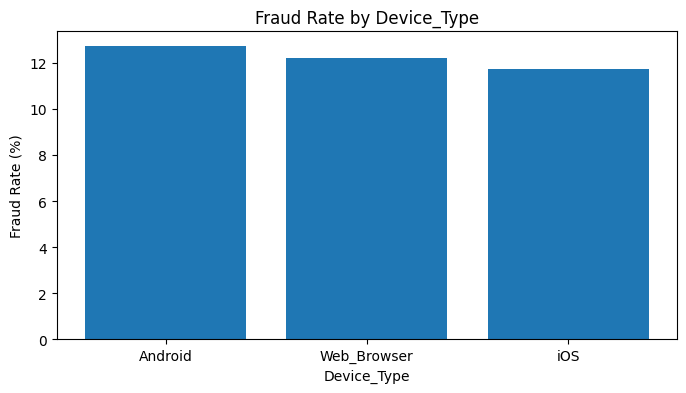


Fraud statistics by Is_Weekend


,count,Fraud_Rate
Is_Weekend,,
0,10703,12.28
1,4297,12.12


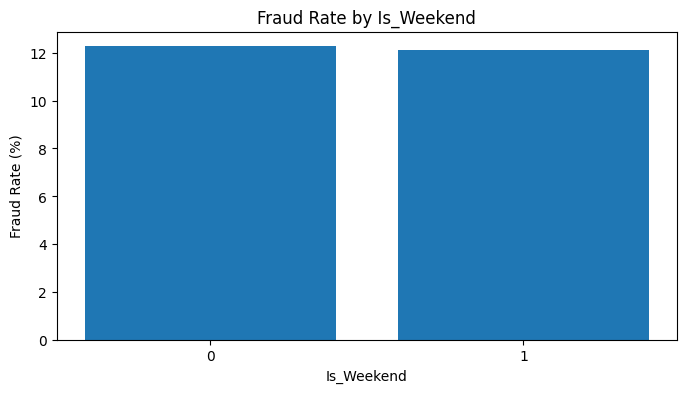


Fraud statistics by Is_Night_Transaction


,count,Fraud_Rate
Is_Night_Transaction,,
0,11883,7.06
1,3117,31.95


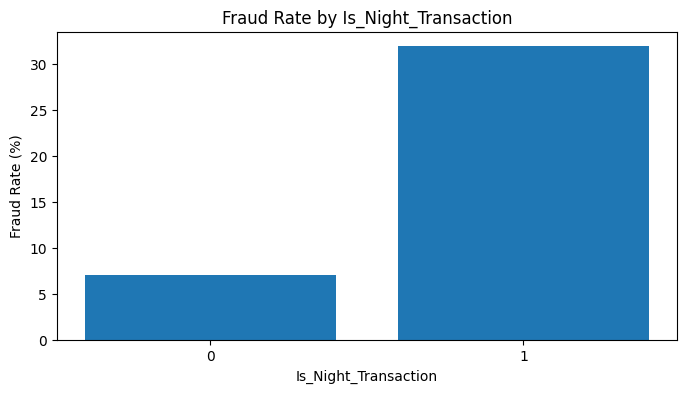

In [21]:
categorical_features = [
    "Merchant_Category",
    "Device_Type",
    "Is_Weekend",
    "Is_Night_Transaction"
]

for column in categorical_features:
    fraud_rate = (
        df_clean
        .groupby(column)["Is_Fraud"]
        .agg(["count", "mean"])
        .rename(columns={"mean": "Fraud_Rate"})
    )

    fraud_rate["Fraud_Rate"] = (
        fraud_rate["Fraud_Rate"] * 100
    ).round(2)

    print(f"\nFraud statistics by {column}")
    display(fraud_rate)

    plt.figure(figsize=(8, 4))
    plt.bar(
        fraud_rate.index.astype(str),
        fraud_rate["Fraud_Rate"]
    )
    plt.title(f"Fraud Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Fraud Rate (%)")
    plt.show()

### Finding

The categorical analysis shows that fraud risk varies across some transaction categories and behavioral conditions. Features with substantially different fraud rates across their categories may provide useful discriminatory information for the model.

Merchant category and device type represent contextual information, while weekend and night indicators represent temporal behavior. The observed fraud rates will be considered during feature selection, but features will not be removed solely because they have weak individual relationships with the target. Some variables may become useful through interactions with other features.

In [22]:
distance_summary = (
    df_clean
    .groupby("Distance_from_Home")["Is_Fraud"]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "sum": "Fraud_Count",
        "mean": "Fraud_Rate"
    })
)

distance_summary["Fraud_Rate"] = (
    distance_summary["Fraud_Rate"] * 100
).round(2)

display(distance_summary)

,count,Fraud_Count,Fraud_Rate
Distance_from_Home,,,
0.0123,14230,1498,10.53
4.8088,770,337,43.77


### Finding

`Distance_from_Home` has only two unique values despite being stored as a numerical variable. Therefore, it behaves more like a binary indicator than a continuous geographic distance measurement.

The fraud rate differs substantially between its two values, indicating a strong association with the target variable. This makes the feature potentially useful for fraud detection, but its semantics should be treated carefully because the dataset does not provide a detailed explanation of how the distance values were generated.

The feature will be retained for the initial modeling stage, but it will be documented as a binary or low-cardinality risk indicator rather than assumed to represent a precise physical distance.

In [23]:
ip_summary = (
    df_clean
    .groupby("Is_Fraud")["IP_Risk_Score"]
    .describe()
    .round(2)
)

display(ip_summary)

,count,mean,std,min,25%,50%,75%,max
Is_Fraud,,,,,,,,
0,13165.0,0.48,0.28,0.0,0.24,0.47,0.72,1.0
1,1835.0,0.66,0.30,0.0,0.39,0.82,0.91,1.0


### Finding

`IP_Risk_Score` shows a clear difference between legitimate and fraudulent transactions, suggesting that higher-risk IP activity is associated with a greater likelihood of fraud.

This is a meaningful feature for the current dataset. However, in a real runtime environment, this score must be obtained from an external IP reputation or risk-scoring mechanism. The model should not rely on a feature that cannot be reproduced during inference.

For the current student project, the feature can be used in the model, but its runtime source will need to be defined during AgentShield integration.

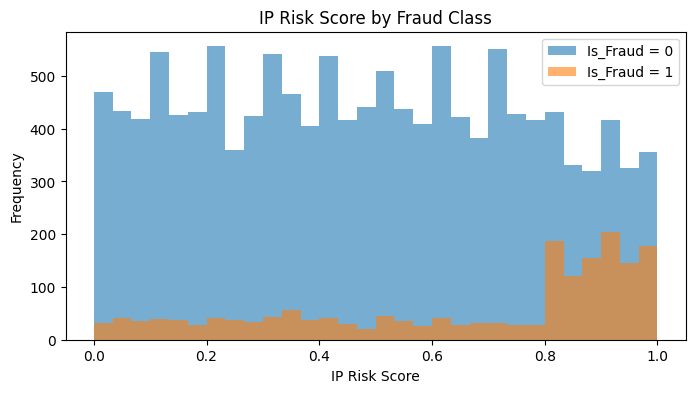

In [24]:
plt.figure(figsize=(8, 4))

for fraud_label, group in df_clean.groupby("Is_Fraud"):
    plt.hist(
        group["IP_Risk_Score"],
        bins=30,
        alpha=0.6,
        label=f"Is_Fraud = {fraud_label}"
    )

plt.title("IP Risk Score by Fraud Class")
plt.xlabel("IP Risk Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Finding

The distribution of `IP_Risk_Score` differs between legitimate and fraudulent transactions. Fraudulent transactions tend to occur more frequently in higher-risk score ranges.

This indicates that IP-related risk is a potentially valuable fraud signal. However, IP risk should be combined with transaction and behavioral features rather than treated as a standalone decision rule.

In [25]:
correlation_features = [
    "Amount",
    "Distance_from_Home",
    "IP_Risk_Score",
    "Avg_Spending_Habit",
    "Is_Weekend",
    "Is_Night_Transaction",
    "Is_Fraud"
]

correlation_matrix = (
    df_clean[correlation_features]
    .corr()
    .round(3)
)

display(correlation_matrix)

,Amount,Distance_from_Home,IP_Risk_Score,Avg_Spending_Habit,Is_Weekend,Is_Night_Transaction,Is_Fraud
Amount,1.000,-0.006,-0.007,-0.009,-0.004,-0.002,0.562
Distance_from_Home,-0.006,1.000,0.002,0.004,0.020,0.003,0.224
IP_Risk_Score,-0.007,0.002,1.000,0.002,0.007,0.009,0.205
Avg_Spending_Habit,-0.009,0.004,0.002,1.000,-0.010,-0.001,-0.018
Is_Weekend,-0.004,0.020,0.007,-0.010,1.000,-0.010,-0.002
Is_Night_Transaction,-0.002,0.003,0.009,-0.001,-0.010,1.000,0.308
Is_Fraud,0.562,0.224,0.205,-0.018,-0.002,0.308,1.000


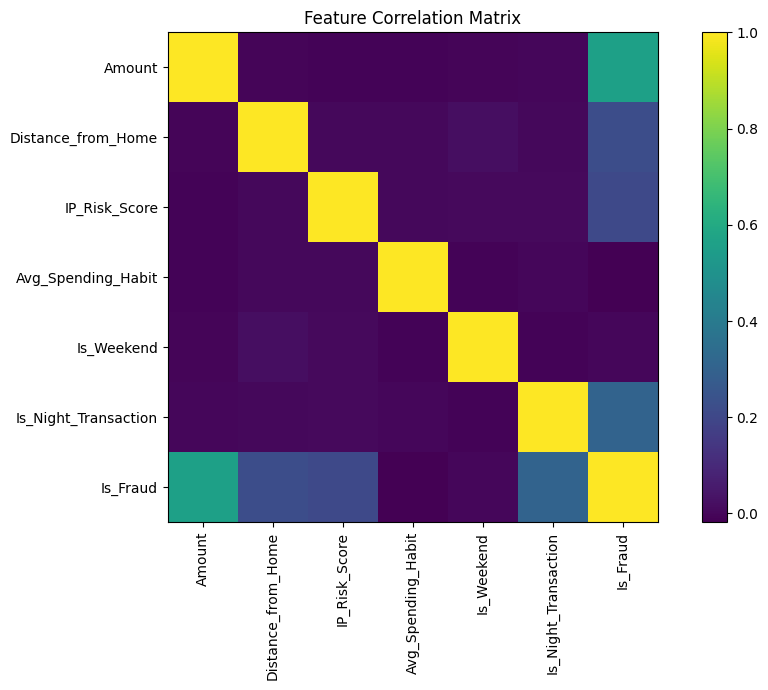

In [26]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix, interpolation="nearest")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.colorbar()
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Finding

The correlation analysis identifies linear relationships among numerical features and their associations with the fraud target.

Features with stronger correlation to `Is_Fraud` may be useful predictors, while highly correlated input features should be monitored for redundancy and multicollinearity. However, correlation alone will not determine the final feature set because categorical variables, nonlinear relationships, and feature interactions are not fully captured by a standard correlation matrix.

In addition, a strong correlation with the fraud target does not automatically indicate target leakage. Each strongly associated feature must be evaluated based on whether it is genuinely available at the time of transaction inference.

In [27]:
# Create a separate copy for feature engineering
df_features = df_clean.copy()

print("Feature engineering dataset shape:", df_features.shape)

Feature engineering dataset shape: (15000, 12)


In [28]:
df_features["Transaction_Hour"] = df_features["Timestamp"].dt.hour
df_features["Day_of_Week"] = df_features["Timestamp"].dt.dayofweek

df_features[[
    "Timestamp",
    "Transaction_Hour",
    "Day_of_Week"
]].head()

,Timestamp,Transaction_Hour,Day_of_Week
0,2025-02-06 18:46:00,18,3
1,2025-03-25 09:19:00,9,1
2,2025-02-17 17:05:00,17,0
3,2025-01-13 08:26:00,8,0
4,2025-03-16 08:38:00,8,6


### Feature Engineering Finding

The raw `Timestamp` column contains highly granular transaction times and should not be used directly as a model feature. Instead, two interpretable temporal features were derived: `Transaction_Hour`, representing the hour of the transaction, and `Day_of_Week`, representing the day of the week.

These engineered features preserve potentially useful temporal patterns while avoiding the extremely high cardinality of the raw timestamp values.

In [29]:
print("Current columns:")
print(df_features.columns.tolist())

Current columns:
['Transaction_ID', 'Timestamp', 'Customer_ID', 'Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction', 'Is_Fraud', 'Transaction_Hour', 'Day_of_Week']


In [30]:
drop_columns = [
    "Transaction_ID",
    "Timestamp",
    "Customer_ID"
]

df_model = df_features.drop(columns=drop_columns).copy()

print("Modeling dataset shape:", df_model.shape)
print("\nFinal columns:")
print(df_model.columns.tolist())

Modeling dataset shape: (15000, 11)

Final columns:
['Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction', 'Is_Fraud', 'Transaction_Hour', 'Day_of_Week']


In [31]:
TARGET_COLUMN = "Is_Fraud"

X = df_model.drop(columns=[TARGET_COLUMN])
y = df_model[TARGET_COLUMN]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nModel features:")
print(X.columns.tolist())

Feature matrix shape: (15000, 10)
Target shape: (15000,)

Model features:
['Amount', 'Merchant_Category', 'Distance_from_Home', 'Device_Type', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction', 'Transaction_Hour', 'Day_of_Week']


### Finding

The final feature set was selected based on three requirements: predictive relevance, availability at runtime, and avoidance of target leakage.

`Transaction_ID` was removed because it is only a unique record identifier. The raw `Timestamp` was removed after deriving interpretable temporal features. `Customer_ID` was removed as a direct feature because the model could memorize customer-specific patterns rather than generalize to unseen customers.

The final model will use transaction amount, merchant category, distance-related risk, device type, IP risk score, historical spending information, transaction timing indicators, and engineered temporal features.

No target or post-transaction outcome variables are included in the feature set. However, `Avg_Spending_Habit` must be treated carefully because, in a production system, it must be calculated using only information available before the transaction being scored.

In [32]:
# Sort transactions chronologically
df_split = df_features.sort_values("Timestamp").reset_index(drop=True)

n = len(df_split)

train_end = int(n * 0.70)
validation_end = int(n * 0.85)

train_df = df_split.iloc[:train_end]
validation_df = df_split.iloc[train_end:validation_end]
test_df = df_split.iloc[validation_end:]

print("Training set:", train_df.shape)
print("Validation set:", validation_df.shape)
print("Test set:", test_df.shape)

Training set: (10500, 14)
Validation set: (2250, 14)
Test set: (2250, 14)


In [33]:
feature_columns = [
    "Amount",
    "Merchant_Category",
    "Distance_from_Home",
    "Device_Type",
    "IP_Risk_Score",
    "Avg_Spending_Habit",
    "Is_Weekend",
    "Is_Night_Transaction",
    "Transaction_Hour",
    "Day_of_Week"
]

target_column = "Is_Fraud"

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_val = validation_df[feature_columns].copy()
y_val = validation_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("\nFeature shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


Feature shapes:
X_train: (10500, 10)
X_val: (2250, 10)
X_test: (2250, 10)


In [34]:
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Rows": [len(y_train), len(y_val), len(y_test)],
    "Fraud_Count": [
        y_train.sum(),
        y_val.sum(),
        y_test.sum()
    ],
    "Fraud_Rate_%": [
        y_train.mean() * 100,
        y_val.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary["Fraud_Rate_%"] = split_summary["Fraud_Rate_%"].round(2)

display(split_summary)

,Dataset,Rows,Fraud_Count,Fraud_Rate_%
0,Training,10500,1308,12.46
1,Validation,2250,257,11.42
2,Test,2250,270,12.00


### Finding

The dataset was split chronologically into training (70%), validation (15%), and test (15%) sets. The model will be trained using historical transactions, while the validation and test sets represent progressively newer transactions.

The validation set will be used for model selection and threshold tuning. The test set will remain untouched until final evaluation.

Because the split is time-based, the fraud rate across the three datasets may not be exactly identical. This is acceptable and more realistic than randomly mixing future transactions into the training data. The class distribution was checked separately in all three splits to ensure that each set contains sufficient fraud examples.

In [35]:
numerical_features = [
    "Amount",
    "Distance_from_Home",
    "IP_Risk_Score",
    "Avg_Spending_Habit",
    "Is_Weekend",
    "Is_Night_Transaction",
    "Transaction_Hour",
    "Day_of_Week"
]

categorical_features = [
    "Merchant_Category",
    "Device_Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Amount', 'Distance_from_Home', 'IP_Risk_Score', 'Avg_Spending_Habit', 'Is_Weekend', 'Is_Night_Transaction', 'Transaction_Hour', 'Day_of_Week']

Categorical features:
['Merchant_Category', 'Device_Type']


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Amount', 'Distance_from_Home',
                                  'IP_Risk_Score', 'Avg_Spending_Habit',
                                  'Is_Weekend', 'Is_Night_Transaction',
                                  'Transaction_Hour', 'Day_of_Week']),
                                ('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Merchant_Category', 'Device_Type'])])

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

X_test_processed = preprocessor.transform(X_test)

print("Processed shapes:")
print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Processed shapes:
Training: (10500, 17)
Validation: (2250, 17)
Test: (2250, 17)


### Finding

The preprocessing pipeline was designed to transform numerical and categorical features while preventing data leakage.

Numerical features were standardized using `StandardScaler`, while categorical features were converted into machine-readable variables using one-hot encoding. The `handle_unknown="ignore"` setting ensures that unseen categories during validation or testing do not cause inference failures.

The preprocessing pipeline was fitted only on the training dataset. The learned transformations were then applied unchanged to the validation and test datasets, preventing information from future data from influencing the training process.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

In [39]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression training completed")

Logistic Regression training completed


In [40]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest training completed")

Random Forest training completed


In [42]:
hist_gradient_model = HistGradientBoostingClassifier(
    max_iter=300,
    random_state=42
)

hist_gradient_model.fit(
    X_train_processed,
    y_train
)

print("HistGradientBoosting training completed")

HistGradientBoosting training completed


### Finding

Three baseline models were trained to evaluate different modeling approaches.

Logistic Regression provides a simple and interpretable linear baseline. Random Forest can capture nonlinear relationships and interactions between fraud-related features. HistGradientBoosting provides an efficient gradient-boosting approach that can model complex nonlinear patterns.

All models were trained using the same training data. Their performance will be compared using the validation dataset, while the test dataset remains untouched until the final evaluation stage.

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [44]:
def evaluate_model(model, X, y, model_name):
    # Predicted classes using the default threshold
    y_pred = model.predict(X)

    # Fraud probabilities
    y_prob = model.predict_proba(X)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-Score": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "PR-AUC": average_precision_score(y, y_prob)
    }

    return results

In [45]:
logistic_results = evaluate_model(
    logistic_model,
    X_val_processed,
    y_val,
    "Logistic Regression"
)

random_forest_results = evaluate_model(
    random_forest_model,
    X_val_processed,
    y_val,
    "Random Forest"
)

hist_gradient_results = evaluate_model(
    hist_gradient_model,
    X_val_processed,
    y_val,
    "HistGradientBoosting"
)

In [46]:
validation_results = pd.DataFrame([
    logistic_results,
    random_forest_results,
    hist_gradient_results
])

validation_results = validation_results.sort_values(
    by=["PR-AUC", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

display(validation_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,HistGradientBoosting,0.9960,0.9921,0.9728,0.9823,0.9999,0.9990
1,Random Forest,0.9947,0.9842,0.9689,0.9765,0.9998,0.9982
2,Logistic Regression,0.9782,0.9444,0.8599,0.9002,0.9931,0.9514


### Finding

The three baseline models were evaluated on the validation dataset using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

Because fraud detection is a classification problem with an imbalanced target distribution, model selection will not be based primarily on accuracy. PR-AUC, ROC-AUC, recall, precision, and F1-score will be considered together when selecting the most appropriate model.

The best-performing model will be selected based on validation performance only. The test dataset will remain untouched until the final model and classification threshold have been selected.


Logistic Regression
[[1980   13]
 [  36  221]]


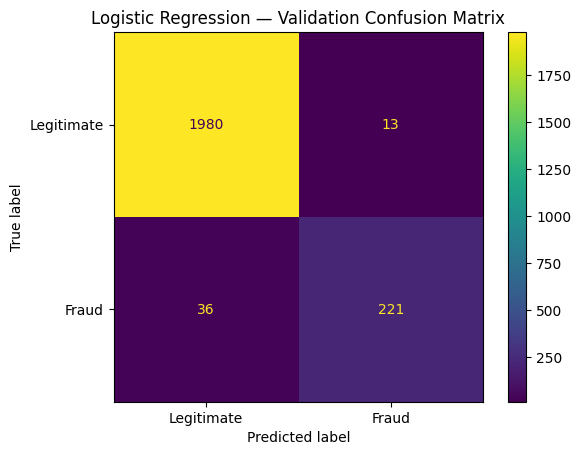


Random Forest
[[1989    4]
 [   8  249]]


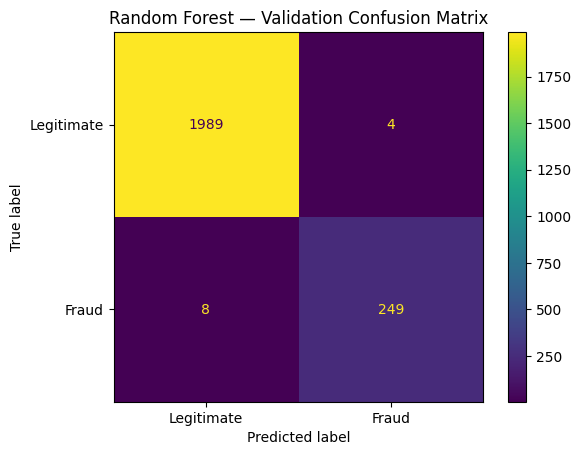


HistGradientBoosting
[[1991    2]
 [   7  250]]


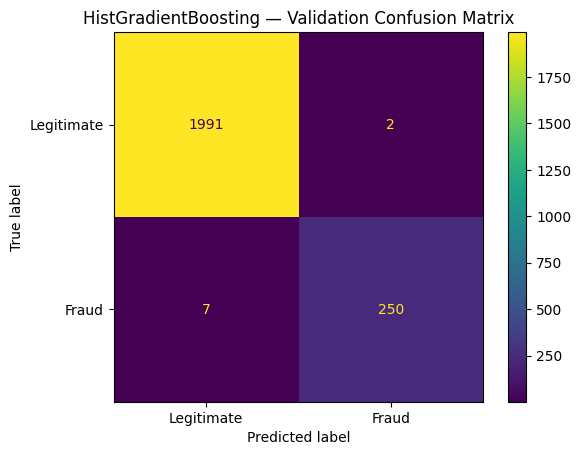

In [48]:
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "HistGradientBoosting": hist_gradient_model
}

for model_name, model in models.items():
    y_pred = model.predict(X_val_processed)

    cm = confusion_matrix(y_val, y_pred)

    print(f"\n{model_name}")
    print(cm)

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Fraud"]
    )

    display.plot()
    plt.title(f"{model_name} — Validation Confusion Matrix")
    plt.show()

### Finding

The confusion matrix analysis shows that HistGradientBoosting produced the strongest validation performance at the default classification threshold of 0.5.

- **Logistic Regression:** Missed 36 fraudulent transactions and incorrectly flagged 13 legitimate transactions as fraud.
- **Random Forest:** Missed 8 fraudulent transactions and incorrectly flagged 4 legitimate transactions.
- **HistGradientBoosting:** Missed only 7 fraudulent transactions and incorrectly flagged only 2 legitimate transactions.

HistGradientBoosting therefore achieved the lowest number of false negatives and false positives among the three baseline models. This is particularly important for the AgentShield fraud-detection use case, where missed fraudulent transactions represent a significant risk.

However, the results should still be interpreted carefully because the extremely low error rates may reflect strong synthetic patterns in the dataset. Therefore, the classification threshold will be optimized using validation data before finalizing the model.

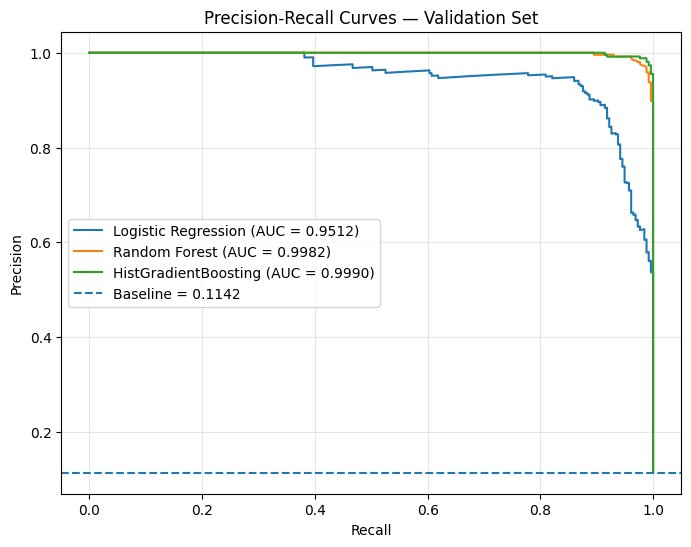

In [49]:
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    y_prob = model.predict_proba(X_val_processed)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_val,
        y_prob
    )

    pr_auc = auc(recall, precision)

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUC = {pr_auc:.4f})"
    )

baseline = y_val.mean()

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Finding

The Precision-Recall curve analysis confirms that the tree-based models significantly outperform Logistic Regression.

HistGradientBoosting achieved the highest PR-AUC of **0.9990**, followed closely by Random Forest with a PR-AUC of **0.9982**. Both models maintained very high precision across most of the recall range. Logistic Regression achieved a lower PR-AUC of **0.9512**, indicating comparatively weaker fraud-class separation.

The baseline precision is approximately **0.1142**, corresponding to the fraud prevalence in the validation dataset. All three models perform substantially above this baseline.

The near-perfect PR-AUC values of HistGradientBoosting and Random Forest indicate that the dataset contains highly separable fraud patterns. While these results are excellent for the current student project, they should not be interpreted as evidence of production-level real-world performance without evaluation on more realistic and independently collected transaction data.

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Get fraud probabilities from the validation set
y_val_prob = hist_gradient_model.predict_proba(
    X_val_processed
)[:, 1]

print("Number of validation probabilities:", len(y_val_prob))

Number of validation probabilities: 2250


In [53]:
# Thresholds from 0.05 to 0.95
thresholds = np.arange(0.05, 0.96, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into predictions
    y_pred_threshold = (
        y_val_prob >= threshold
    ).astype(int)

    # Confusion matrix
    cm = confusion_matrix(
        y_val,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    # Store results
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

# Convert to DataFrame
threshold_results_df = pd.DataFrame(
    threshold_results
)

# Print results
print(
    threshold_results_df.round(4).to_string(
        index=False
    )
)

 Threshold  Precision  Recall  F1-Score  False_Positives  False_Negatives  True_Positives
      0.05     0.9697  0.9961    0.9827                8                1             256
      0.10     0.9770  0.9922    0.9846                6                2             255
      0.15     0.9808  0.9922    0.9865                5                2             255
      0.20     0.9807  0.9883    0.9845                5                3             254
      0.25     0.9883  0.9883    0.9883                3                3             254
      0.30     0.9882  0.9767    0.9824                3                6             251
      0.35     0.9882  0.9767    0.9824                3                6             251
      0.40     0.9921  0.9767    0.9843                2                6             251
      0.45     0.9921  0.9767    0.9843                2                6             251
      0.50     0.9921  0.9728    0.9823                2                7             250
      0.55

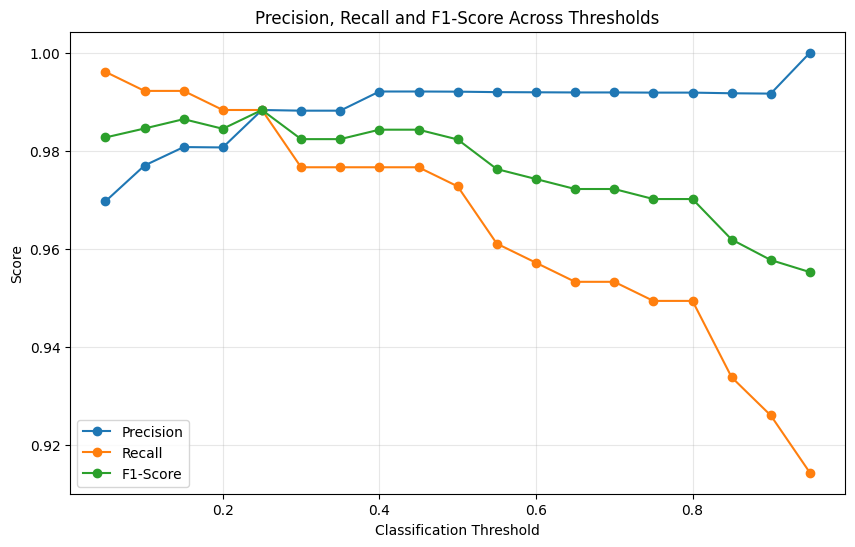

In [55]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-Score Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

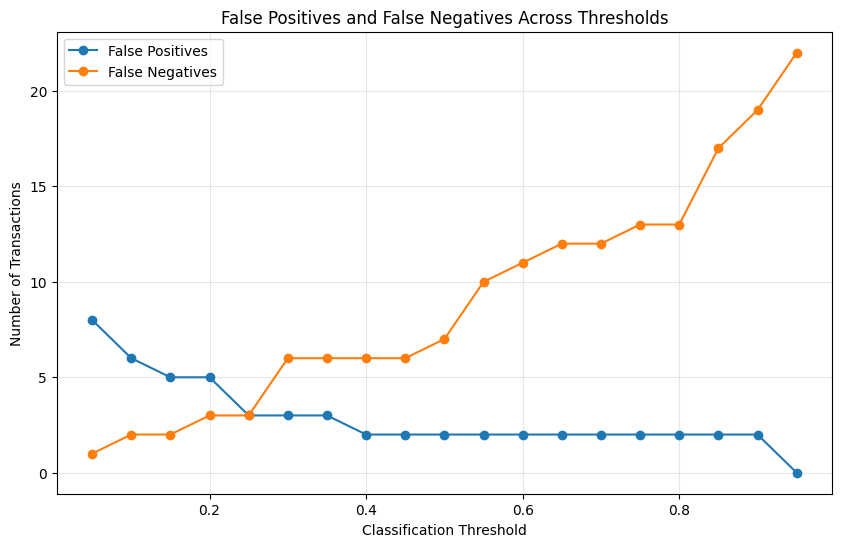

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False_Positives"],
    marker="o",
    label="False Positives"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["False_Negatives"],
    marker="o",
    label="False Negatives"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Transactions")
plt.title("False Positives and False Negatives Across Thresholds")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [57]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1-Score"].idxmax()
]

print("Best threshold by F1-score:")
print(best_f1_row.round(4).to_string())

Best threshold by F1-score:
Threshold            0.2500
Precision            0.9883
Recall               0.9883
F1-Score             0.9883
False_Positives      3.0000
False_Negatives      3.0000
True_Positives     254.0000


Brier Score: 0.003327


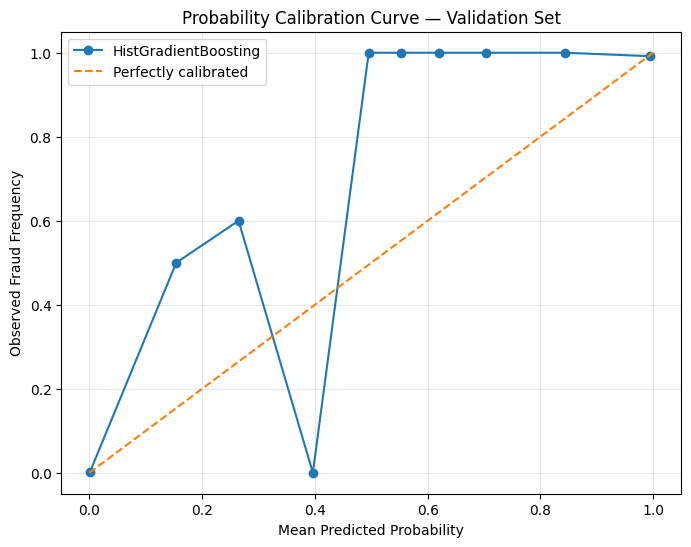

In [58]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Get validation probabilities
y_val_prob = hist_gradient_model.predict_proba(
    X_val_processed
)[:, 1]

# Brier score
brier_score = brier_score_loss(
    y_val,
    y_val_prob
)

print(f"Brier Score: {brier_score:.6f}")

# Calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_val,
    y_val_prob,
    n_bins=10,
    strategy="uniform"
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="HistGradientBoosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfectly calibrated"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Frequency")
plt.title("Probability Calibration Curve — Validation Set")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [59]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    average_precision_score,
    roc_auc_score
)

# Create a calibrated version of the existing candidate model.
# cv="prefit" calibrates using the validation data.
calibrated_hist_gradient_model = CalibratedClassifierCV(
    estimator=hist_gradient_model,
    method="sigmoid",
    cv="prefit"
)

# Fit the calibration layer on validation data
calibrated_hist_gradient_model.fit(
    X_val_processed,
    y_val
)

# Get calibrated validation probabilities
y_val_prob_calibrated = calibrated_hist_gradient_model.predict_proba(
    X_val_processed
)[:, 1]

# Compare metrics
raw_brier = brier_score_loss(
    y_val,
    y_val_prob
)

calibrated_brier = brier_score_loss(
    y_val,
    y_val_prob_calibrated
)

print(f"Raw Brier Score:        {raw_brier:.6f}")
print(f"Calibrated Brier Score: {calibrated_brier:.6f}")

print(
    f"Calibrated ROC-AUC: {roc_auc_score(y_val, y_val_prob_calibrated):.6f}"
)

print(
    f"Calibrated PR-AUC:  {average_precision_score(y_val, y_val_prob_calibrated):.6f}"
)

Raw Brier Score:        0.003327
Calibrated Brier Score: 0.002687
Calibrated ROC-AUC: 0.999875
Calibrated PR-AUC:  0.999020


/usr/local/lib/python3.13/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


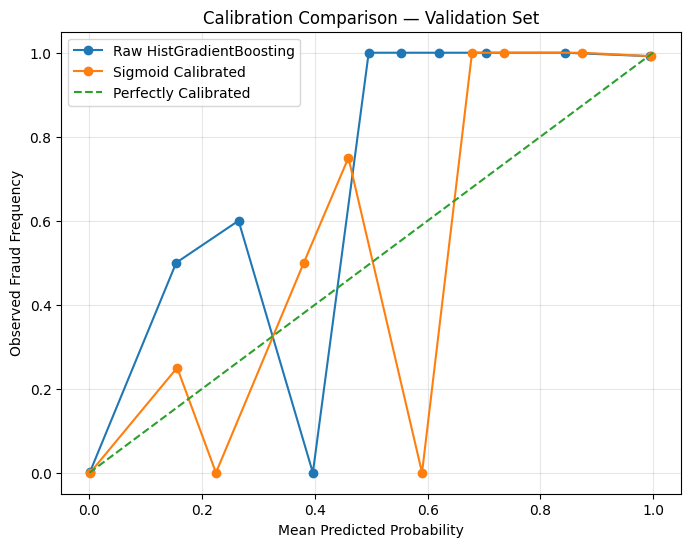

In [60]:
from sklearn.calibration import calibration_curve

raw_fraction, raw_mean = calibration_curve(
    y_val,
    y_val_prob,
    n_bins=10,
    strategy="uniform"
)

calibrated_fraction, calibrated_mean = calibration_curve(
    y_val,
    y_val_prob_calibrated,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    raw_mean,
    raw_fraction,
    marker="o",
    label="Raw HistGradientBoosting"
)

plt.plot(
    calibrated_mean,
    calibrated_fraction,
    marker="o",
    label="Sigmoid Calibrated"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfectly Calibrated"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraud Frequency")
plt.title("Calibration Comparison — Validation Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Finding

Sigmoid calibration improved the Brier Score from **0.003327** to **0.002687**, indicating a modest improvement in overall probability accuracy. However, the calibration curve remained irregular across the probability range, likely due to highly confident predictions and limited observations within some probability bins.

The calibrated model maintained a nearly identical ROC-AUC, but its PR-AUC decreased from approximately **0.9990** to **0.9902**.

Because the calibration layer was fitted using the validation dataset, the calibrated validation performance should not be treated as an independent estimate of generalization performance. Additionally, the synthetic dataset produces highly separable fraud patterns, resulting in probabilities concentrated near the extremes.

Therefore, for the current student project, the raw HistGradientBoosting model will remain the final candidate model. Probability calibration has been investigated and documented, but the calibrated version will not automatically replace the original model.

In [61]:
fine_thresholds = np.arange(0.15, 0.351, 0.01)

fine_threshold_results = []

for threshold in fine_thresholds:

    y_pred_threshold = (
        y_val_prob >= threshold
    ).astype(int)

    cm = confusion_matrix(
        y_val,
        y_pred_threshold
    )

    tn, fp, fn, tp = cm.ravel()

    fine_threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    })

fine_threshold_results_df = pd.DataFrame(
    fine_threshold_results
)

print(
    fine_threshold_results_df.round(4).to_string(
        index=False
    )
)

 Threshold  Precision  Recall  F1-Score  False_Positives  False_Negatives  True_Positives
      0.15     0.9808  0.9922    0.9865                5                2             255
      0.16     0.9808  0.9922    0.9865                5                2             255
      0.17     0.9808  0.9922    0.9865                5                2             255
      0.18     0.9808  0.9922    0.9865                5                2             255
      0.19     0.9808  0.9922    0.9865                5                2             255
      0.20     0.9807  0.9883    0.9845                5                3             254
      0.21     0.9807  0.9883    0.9845                5                3             254
      0.22     0.9807  0.9883    0.9845                5                3             254
      0.23     0.9845  0.9883    0.9864                4                3             254
      0.24     0.9845  0.9883    0.9864                4                3             254
      0.25

In [62]:
best_threshold_row = fine_threshold_results_df.loc[
    fine_threshold_results_df["F1-Score"].idxmax()
]

print("Best threshold in fine-grained search:")
print(best_threshold_row.round(4).to_string())

Best threshold in fine-grained search:
Threshold            0.2500
Precision            0.9883
Recall               0.9883
F1-Score             0.9883
False_Positives      3.0000
False_Negatives      3.0000
True_Positives     254.0000


### Finding

A fine-grained threshold search from 0.15 to 0.35 was performed using the validation dataset.

The optimal threshold was selected as **0.25**, producing a precision of **0.9883**, recall of **0.9883**, and F1-score of **0.9883**. At this threshold, the model produced only **3 false positives** and **3 false negatives**.

Thresholds below 0.25 slightly increased recall but generated more false positives. Thresholds above 0.25 did not provide a meaningful improvement in precision and gradually increased the number of fraudulent transactions missed by the model.

Therefore, **0.25** was selected as the final fraud classification threshold based on validation performance.

The final candidate configuration is:

- Model: HistGradientBoostingClassifier
- Probability source: Raw model probabilities
- Fraud classification threshold: 0.25

In [63]:
# Final candidate configuration
FINAL_THRESHOLD = 0.25

# Get raw fraud probabilities from the untouched test set
y_test_prob = hist_gradient_model.predict_proba(
    X_test_processed
)[:, 1]

# Apply the finalized threshold
y_test_pred = (
    y_test_prob >= FINAL_THRESHOLD
).astype(int)

# Confusion matrix
cm_test = confusion_matrix(
    y_test,
    y_test_pred
)

tn, fp, fn, tp = cm_test.ravel()

# Calculate final metrics
final_test_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "F1-Score": f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        y_test_prob
    ),
    "PR-AUC": average_precision_score(
        y_test,
        y_test_prob
    ),
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp,
    "True Negatives": tn
}

final_test_results_df = pd.DataFrame(
    [final_test_results]
)

print(
    final_test_results_df.round(6).to_string(
        index=False
    )
)

 Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC  False Positives  False Negatives  True Positives  True Negatives
 0.997333   0.981752 0.996296  0.988971 0.999899 0.999272                5                1             269            1975


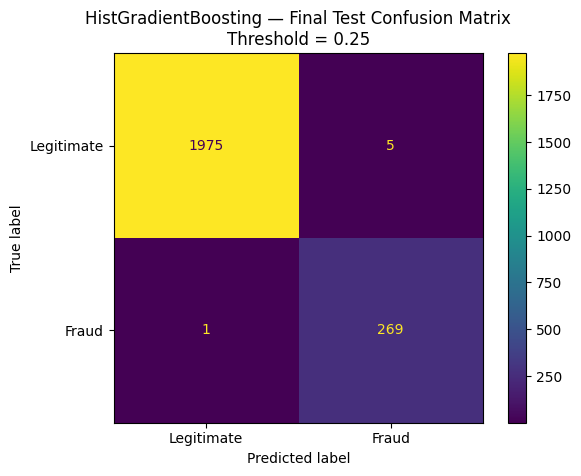

In [64]:
cm_test_display = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["Legitimate", "Fraud"]
)

cm_test_display.plot()

plt.title(
    "HistGradientBoosting — Final Test Confusion Matrix\n"
    f"Threshold = {FINAL_THRESHOLD}"
)

plt.show()

### Finding

The final HistGradientBoosting model was evaluated once on the untouched test dataset using the previously finalized fraud classification threshold of **0.25**.

The model achieved an accuracy of **0.9973**, precision of **0.9818**, recall of **0.9963**, F1-score of **0.9890**, ROC-AUC of **0.9999**, and PR-AUC of **0.9993**.

The final confusion matrix showed **1975 true negatives, 5 false positives, 1 false negative, and 269 true positives**. Therefore, the model detected **269 out of 270 fraudulent transactions** while incorrectly flagging only **5 legitimate transactions**.

These results demonstrate very strong performance on the held-out test set. However, because the dataset contains highly separable and synthetic fraud patterns, these results should not be interpreted as evidence of production-level real-world fraud detection performance.

In [65]:
from scipy.sparse import vstack

X_final_train_processed = vstack([
    X_train_processed,
    X_val_processed
])

y_final_train = np.concatenate([
    np.asarray(y_train),
    np.asarray(y_val)
])

print("Final training feature shape:", X_final_train_processed.shape)
print("Final training target shape:", y_final_train.shape)

Final training feature shape: (12750, 17)
Final training target shape: (12750,)


In [67]:
final_fraud_model = HistGradientBoostingClassifier(
    max_iter=300,
    random_state=42
)

final_fraud_model.fit(
    X_final_train_processed,
    y_final_train
)

print("Final HistGradientBoosting model training completed.")

Final HistGradientBoosting model training completed.


In [68]:
print("Model type:", type(final_fraud_model).__name__)
print("Model iterations:", final_fraud_model.n_iter_)

print("\nFinal model configuration:")
print("max_iter:", final_fraud_model.max_iter)
print("random_state:", final_fraud_model.random_state)

print("\nFinal fraud threshold:", 0.25)

Model type: HistGradientBoostingClassifier
Model iterations: 64

Final model configuration:
max_iter: 300
random_state: 42

Final fraud threshold: 0.25


### Finding

After completing model selection and threshold optimization, the final deployable HistGradientBoosting model was retrained using the combined training and validation datasets.

The final model configuration was fixed before retraining:

- Model: HistGradientBoostingClassifier
- Maximum iterations: 300
- Random state: 42
- Fraud classification threshold: 0.25

The untouched test dataset was excluded from final model training. It had already been used only for one-time final performance evaluation.

Combining the training and validation datasets allows the final model to learn from more approved pre-test examples while preserving the separation of the test dataset from the model development process.

In [69]:
from pathlib import Path
import joblib
import json
import sklearn
from datetime import datetime, timezone

ARTIFACT_DIR = Path("agent_shield_fraud_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Artifact directory: {ARTIFACT_DIR.resolve()}")

Artifact directory: /content/agent_shield_fraud_artifacts


In [70]:
MODEL_PATH = ARTIFACT_DIR / "fraud_model.joblib"

joblib.dump(
    final_fraud_model,
    MODEL_PATH
)

print(f"Model saved successfully: {MODEL_PATH}")

Model saved successfully: agent_shield_fraud_artifacts/fraud_model.joblib


In [71]:
PREPROCESSOR_PATH = ARTIFACT_DIR / "preprocessor.joblib"

# Check the expected preprocessing object
if "preprocessor" not in globals():
    raise NameError(
        "The variable 'preprocessor' was not found. "
        "Run your preprocessing cell and verify the variable name "
        "before saving the artifact."
    )

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

print(f"Preprocessor saved successfully: {PREPROCESSOR_PATH}")

Preprocessor saved successfully: agent_shield_fraud_artifacts/preprocessor.joblib


In [72]:
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

model_metadata = {
    "model_name": "HistGradientBoostingClassifier",
    "model_version": "1.0.0",
    "model_iterations": int(final_fraud_model.n_iter_),

    "model_parameters": {
        "max_iter": 300,
        "random_state": 42
    },

    "prediction": {
        "positive_class": "fraud",
        "probability_method": "predict_proba",
        "probability_index": 1,
        "fraud_classification_threshold": 0.25
    },

    "test_performance": {
        "accuracy": 0.997333,
        "precision": 0.981752,
        "recall": 0.996296,
        "f1_score": 0.988971,
        "roc_auc": 0.999899,
        "pr_auc": 0.999272,
        "false_positives": 5,
        "false_negatives": 1,
        "true_positives": 269,
        "true_negatives": 1975
    },

    "training": {
        "final_training_data": "combined_train_and_validation",
        "test_set_used_for_final_training": False,
        "fraud_threshold_selected_on": "validation_set"
    },

    "libraries": {
        "scikit_learn": sklearn.__version__
    },

    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat()
}

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print(f"Metadata saved successfully: {METADATA_PATH}")

Metadata saved successfully: agent_shield_fraud_artifacts/model_metadata.json


In [73]:
print("Final ML artifacts:\n")

for file_path in ARTIFACT_DIR.iterdir():
    if file_path.is_file():
        size_kb = file_path.stat().st_size / 1024

        print(
            f"{file_path.name} "
            f"({size_kb:.2f} KB)"
        )

Final ML artifacts:

preprocessor.joblib (3.59 KB)
fraud_model.joblib (234.96 KB)
model_metadata.json (1.00 KB)
